## EDA

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("data/ta_restaurants.csv")
df.head()

,rating,reviews_count,cuisine_type,price,is_sponsored
0,"5,0",3,"Средиземноморская, Греческая",$$ - $$$,True
1,"4,1",97,"Бары и клубы, Стейк-хаус",$$ - $$$,True
2,"4,8",3316,"Французская, Стейк-хаус",$$$$,False
3,"4,3",518,"Китайская, Японская",$,False
4,"4,7",3995,"Итальянская, Пицца",$$ - $$$,False


In [3]:
df.shape

(10499, 5)

In [4]:
df['rating'] = df['rating'].str.replace(',', '.').astype('float')

In [5]:
df.isna().sum()

rating           1818
reviews_count       0
cuisine_type      293
price            4234
is_sponsored        0
dtype: int64

In [6]:
df = df.dropna(subset=['rating', 'price', 'cuisine_type'])

In [7]:
price_levels = {'$': 1, '$$': 2, '$$$': 3, '$$$$': 4, '$$$$$': 5}

df['lowest_price'] = df['price'].str.replace(' ', '').str.split('-').str[0].map(price_levels)
df['max_price'] = df['price'].str.replace(' ', '').str.split('-').str[-1].map(price_levels)

In [8]:
df

,rating,reviews_count,cuisine_type,price,is_sponsored,lowest_price,max_price
0,5.0,3,"Средиземноморская, Греческая",$$ - $$$,True,2,3
1,4.1,97,"Бары и клубы, Стейк-хаус",$$ - $$$,True,2,3
2,4.8,3316,"Французская, Стейк-хаус",$$$$,False,4,4
3,4.3,518,"Китайская, Японская",$,False,1,1
4,4.7,3995,"Итальянская, Пицца",$$ - $$$,False,2,3
...,...,...,...,...,...,...,...
10463,4.6,56,"Итальянская, Пицца",$$ - $$$,True,2,3
10464,4.5,130,"Бары и клубы, Ирландская",$,True,1,1
10465,4.6,56,"Итальянская, Пицца",$$ - $$$,True,2,3
10482,4.5,27,"Японская, Азиатская",$$ - $$$,True,2,3


In [9]:
df = df[~df['cuisine_type'].fillna('').str.contains(
    r'Откроется|Закроется|Открыто|Сейчас|Сегодня|Меню', regex=True)]

In [10]:
cuisine_dummies = df['cuisine_type'].str.get_dummies(sep=', ')
cuisine_dummies.columns = cuisine_dummies.columns.str.replace(' ', '_').str.replace('-', '_')
cuisine_dummies.columns.tolist()

['Австралийская',
 'Австрийская',
 'Азиатская',
 'Американская',
 'Аргентинская',
 'Армянская',
 'Афганская',
 'Африканская',
 'Бангладешская',
 'Бар',
 'Барбекю',
 'Бары_и_клубы',
 'Бары_с_рестораном',
 'Баскская',
 'Бельгийская',
 'Ближневосточная',
 'Бразильская',
 'Британская',
 'Венесуэльская',
 'Винный_бар',
 'Восточноевропейская',
 'Вьетнамская',
 'Гавайская',
 'Гастроном',
 'Гастропаб',
 'Греческая',
 'Гриль',
 'Грузинская',
 'Десерты',
 'Европейская',
 'Закусочная',
 'Здоровая',
 'Израильская',
 'Индийская',
 'Ирландская',
 'Испанская',
 'Итальянская',
 'Каджунская_и_креольская',
 'Кайсэки',
 'Канадская',
 'Кантонская',
 'Карибская',
 'Кафе',
 'Китайская',
 'Корейская',
 'Кубинская',
 'Латиноамериканская',
 'Ливанская',
 'Малазийская',
 'Марокканская',
 'Международная',
 'Мексиканская',
 'Морепродукты',
 'Немецкая',
 'Нонья',
 'Паб',
 'Паб_с_пивоварней',
 'Пакистанская',
 'Персидская',
 'Перуанская',
 'Пицца',
 'Польская',
 'Португальская',
 'Римская',
 'Русская',
 'Северно_ит

In [11]:
df = pd.concat([df, cuisine_dummies], axis=1)

In [12]:
df

,rating,reviews_count,cuisine_type,price,is_sponsored,lowest_price,max_price,Австралийская,Австрийская,Азиатская,...,Шведская,Швейцарская,Шриланкийская,Эфиопская,Юговосточная,Южноамериканская,Юнаньская,Ямайская,Японская,Японская_кухня_фьюжн
0,5.0,3,"Средиземноморская, Греческая",$$ - $$$,True,2,3,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4.1,97,"Бары и клубы, Стейк-хаус",$$ - $$$,True,2,3,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4.8,3316,"Французская, Стейк-хаус",$$$$,False,4,4,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4.3,518,"Китайская, Японская",$,False,1,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,4.7,3995,"Итальянская, Пицца",$$ - $$$,False,2,3,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10463,4.6,56,"Итальянская, Пицца",$$ - $$$,True,2,3,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10464,4.5,130,"Бары и клубы, Ирландская",$,True,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10465,4.6,56,"Итальянская, Пицца",$$ - $$$,True,2,3,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10482,4.5,27,"Японская, Азиатская",$$ - $$$,True,2,3,0,0,1,...,0,0,0,0,0,0,0,0,1,0


<Axes: xlabel='rating', ylabel='Count'>

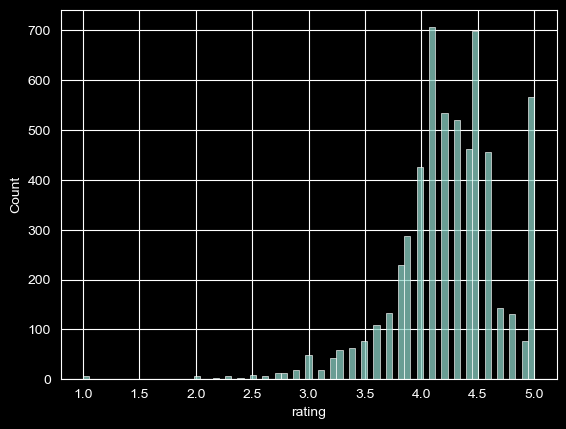

In [13]:
sns.histplot(data=df, x='rating')

In [18]:
pivot_rating = df.groupby(['lowest_price', 'max_price'])['rating'].mean().reset_index()

In [23]:
corr_df = pivot_rating.corr()
corr_df

,lowest_price,max_price,rating
lowest_price,1.000000,0.928571,0.801100
max_price,0.928571,1.000000,0.966026
rating,0.801100,0.966026,1.000000


<Axes: >

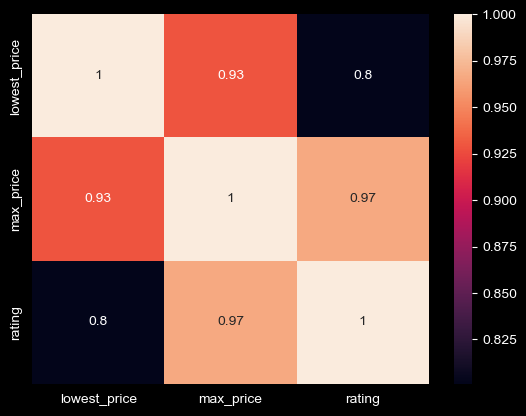

In [22]:
sns.heatmap(corr_df, annot=True)